## Experiment 3: Effect of Vector Size on Query Performance

### Overview
This experiment evaluates how modifying DuckDB’s internal batch size (`STANDARD_VECTOR_SIZE`) affects query performance. By running aggregation-heavy (Q1) and filter/scan-heavy (Q6) queries across different vector sizes, we study how batch size influences execution efficiency.

The experiment highlights the tradeoff between:
- smaller vectors → higher overhead due to more chunks  
- larger vectors → better throughput but potential cache inefficiency  

Since DuckDB processes data in fixed-size chunks throughout its execution pipeline, changing this parameter directly impacts how operators handle data.

### Source Code Pointers
- `src/common/types/data_chunk.cpp` — chunk-based data processing
- `src/common/types/vector.cpp` — vector representation inside chunks
- `src/execution/physical_operator.cpp` — operators processing chunks
- `STANDARD_VECTOR_SIZE` (defined in core headers) — controls batch size across execution
- `src/include/duckdb/common/types/vector_size.hpp` - `STANDARD_VECTOR_SIZE` header

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# change path if needed
df = pd.read_csv("goldilocks_vector_size_results.csv")

df

,vector_size,q1_run1,q1_run2,q1_run3,q1_avg,q6_run1,q6_run2,q6_run3,q6_avg
0,64,0.037179,0.035033,0.036021,0.036078,0.040797,0.036572,0.037344,0.038237
1,512,0.033467,0.032756,0.033714,0.033312,0.032419,0.033261,0.032145,0.032609
2,2048,0.036924,0.035185,0.034196,0.035435,0.098360,0.037451,0.036790,0.057534
3,8192,0.035361,0.033580,0.035927,0.034956,0.032398,0.033870,0.044972,0.037080


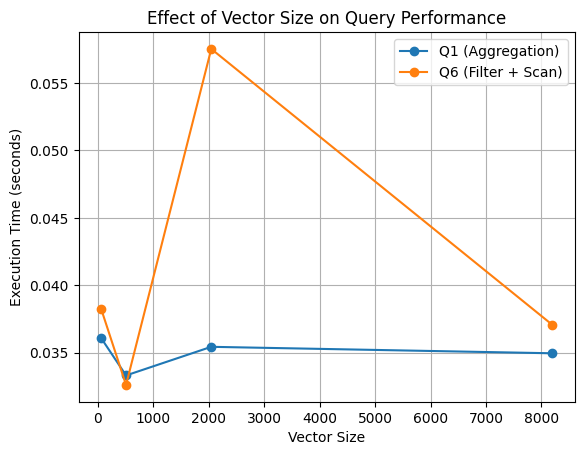

In [3]:
plt.figure()

plt.plot(df["vector_size"], df["q1_avg"], marker='o', label="Q1 (Aggregation)")
plt.plot(df["vector_size"], df["q6_avg"], marker='o', label="Q6 (Filter + Scan)")

plt.xlabel("Vector Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Effect of Vector Size on Query Performance")

plt.legend()
plt.grid()

plt.show()

## Key Insights

- **Existence of an optimal vector size (Goldilocks zone)**  
  Performance is not linear with vector size. Very small and very large vector sizes both lead to suboptimal performance, indicating the presence of an optimal intermediate size.

- **Small vector sizes increase overhead**  
  At lower vector sizes (e.g., 64, 512), execution involves processing many small batches, leading to higher overhead from frequent function calls and reduced efficiency.

- **Large vector sizes can hurt cache efficiency**  
  At very large vector sizes (e.g., 8192), performance degrades slightly due to poorer CPU cache utilization and increased memory pressure.

- **Moderate vector sizes perform best overall**  
  Around the default range (e.g., ~2048), performance is relatively stable and efficient, balancing computation and memory access.

- **Workload sensitivity to vector size**  
  The filter-heavy query (Q6) shows higher sensitivity to vector size compared to the aggregation query (Q1), indicating that different workloads benefit differently from vector tuning.

- **Trade-off between parallelism and memory locality**  
  Smaller vectors improve locality but reduce throughput, while larger vectors improve throughput but may exceed cache limits. The best performance comes from balancing these two factors.

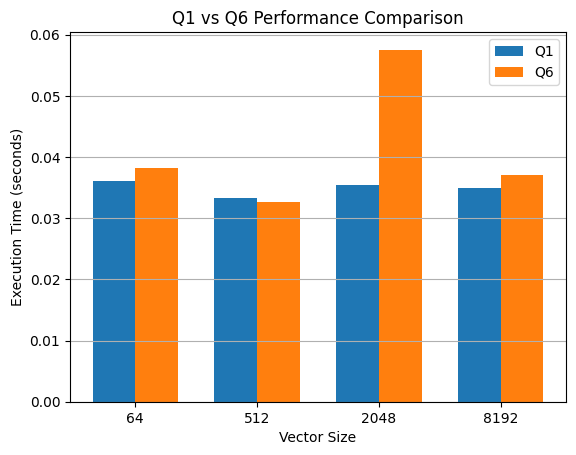

In [4]:
import numpy as np

x = np.arange(len(df["vector_size"]))
width = 0.35

plt.figure()

plt.bar(x - width/2, df["q1_avg"], width, label="Q1")
plt.bar(x + width/2, df["q6_avg"], width, label="Q6")

plt.xticks(x, df["vector_size"])

plt.xlabel("Vector Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Q1 vs Q6 Performance Comparison")

plt.legend()
plt.grid(axis='y')

plt.show()

## Key Insights

- **Q6 is consistently more expensive than Q1**  
  Across all vector sizes, the filter-heavy query (Q6) takes more time than the aggregation query (Q1), indicating higher computational cost due to filtering conditions and arithmetic operations.

- **Best performance observed at moderate vector size (512)**  
  Both Q1 and Q6 achieve their lowest execution times around vector size 512, suggesting this is the most efficient configuration for this workload.

- **Performance degradation at larger vector sizes**  
  At vector size 2048, Q6 shows a significant slowdown, highlighting that larger vectors can negatively impact performance due to cache inefficiency and increased memory pressure.

- **Q1 remains relatively stable across vector sizes**  
  The aggregation query (Q1) shows minimal variation, indicating that aggregation operations are less sensitive to vector size changes.

- **Q6 is highly sensitive to vector size tuning**  
  The noticeable fluctuation in Q6 performance suggests that filter + scan workloads are more affected by vector size, making tuning more critical for such queries.

- **Clear trade-off between efficiency and scalability**  
  Smaller to moderate vector sizes improve execution time, while excessively large vector sizes reduce efficiency, reinforcing the importance of choosing an optimal configuration.